# 🏠 Housing Affordability Analysis — Phase 3: Exploratory Data Analysis
### Analysing US Housing Market Trends Across 5 Major Cities (2015–2024)

| | |
|---|---|
| **Author** | Yaw Assensoh Opoku |
| **Cities** | New York · Los Angeles · Chicago · Houston · Miami |
| **Period** | January 2015 — December 2024 |
| **Tools** | Python · Pandas · Matplotlib · Seaborn · Plotly |
| **Phase** | 3 of 3 — Python Analysis |

## Step 1: Import Libraries 

In [21]:
## Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings('ignore')

# Visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.1)

# Display settings
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', 20)

# City color palette — used consistently across all charts
CITY_COLORS = {
    'Chicago, IL':     '#28A745',
    'Houston, TX':     '#B84FD8',
    'Los Angeles, CA': '#FF6B35',
    'Miami, FL':       '#FF3860',
    'New York, NY':    '#2D87F0',
}
CITIES = list(CITY_COLORS.keys())
COLORS = list(CITY_COLORS.values())

print(" Libraries imported successfully")
print(f"   Pandas:  {pd.__version__}")
print(f"   NumPy:   {np.__version__}")
print(f"   Seaborn: {sns.__version__}")

 Libraries imported successfully
   Pandas:  2.3.3
   NumPy:   2.4.3
   Seaborn: 0.13.2


## Step 2: Load Dataset

In [27]:
## Load Dataset

cities_long    = pd.read_csv('../data/cleaned/cities_long.csv')
annual_summary = pd.read_csv('../data/cleaned/annual_summary.csv')
income         = pd.read_csv('../data/cleaned/income_clean.csv')

# Parse date column
cities_long['date'] = pd.to_datetime(cities_long['date'])

print(f" cities_long     → {cities_long.shape[0]:,} rows × {cities_long.shape[1]} columns")
print(f" annual_summary  → {annual_summary.shape[0]:,} rows × {annual_summary.shape[1]} columns")
print(f" income          → {income.shape[0]:,} rows × {income.shape[1]} columns")
print(f"\nDate range : {cities_long['date'].min().strftime('%b %Y')} → {cities_long['date'].max().strftime('%b %Y')}")
print(f"Cities     : {sorted(cities_long['city'].unique().tolist())}")
display(cities_long.describe())

 cities_long     → 600 rows × 8 columns
 annual_summary  → 50 rows × 7 columns
 income          → 10 rows × 2 columns

Date range : Jan 2015 → Dec 2024
Cities     : ['Chicago, IL', 'Houston, TX', 'Los Angeles, CA', 'Miami, FL', 'New York, NY']


,date,year,month,home_value,monthly_rent,median_income,affordability_index
count,600,600.00,600.00,600.00,596.00,600.00,600.00
mean,2020-01-14 21:24:00,"2,019.50",6.50,"408,803.79","1,943.18","79,461.00",1.02
min,2015-01-31 00:00:00,"2,015.00",1.00,"177,087.00","1,187.00","72,790.00",0.49
25%,2017-07-23 06:00:00,"2,017.00",3.75,"237,120.25","1,515.00","76,710.00",0.60
50%,2020-01-15 12:00:00,"2,019.50",6.50,"312,274.50","1,814.50","80,385.00",0.76
75%,2022-07-07 18:00:00,"2,022.00",9.25,"523,772.75","2,340.25","82,690.00",1.38
max,2024-12-31 00:00:00,"2,024.00",12.00,"953,985.00","3,126.00","83,730.00",2.28
std,NaN,2.87,3.45,"197,826.30",519.09,"3,505.40",0.48


## Step 3: Data Cleaning & Validation
> Validate data quality across 6 dimensions and handle missing values before analysis.

In [48]:
## Cleaning and Processing
print("=" * 60)
print("Data Cleaning and Processing")
print("=" * 60)

#1. Duplicate Check
dupes = cities_long.duplicated().sum()
print(f"\n1. Duplicate rows: {dupes:,}{' (none)' if dupes == 0 else '' }")

#2. Missing Values
missing = cities_long.isnull().sum()
print(f"\n2. Missing values :")
for col, count in missing.items():
    status = "" if count == 0 else f" {count:,} missing"
    print(f"   - {col:<25} {count} missing{status}")

#3. Row count
expected_rows = 5 * 12 * 10  
print(f"\n3. Row count:  {len(cities_long)} "
      f"(expected: {expected_rows:,} "
      f"{'' if len(cities_long) == expected_rows else '⚠️'}")  

#4. Affordability index range
ai_check = cities_long['affordability_index'].between(0, 100).all()
print(f"\n4. Affordability index range (0-100): "
      f"{' Valid' if ai_check else '⚠️ Invalid'}")

#5. City names    
city_count = cities_long['city'].nunique()
print(f"\n5. Cities present:   {city_count} "
      f"{'' if city_count == 5 else '⚠️'}")
for city in sorted(cities_long['city'].unique()):
    rows = len(cities_long[cities_long['city'] == city])
    print(f"   - {city:<25} {rows:,} rows")

#6. Impute missing rent with city monthly median
cities_long['monthly_rent'] = cities_long.groupby(
    ['city', 'month'])['monthly_rent'].transform(lambda x: x.fillna(x.median()))

missing_after = cities_long['monthly_rent'].isnull().sum()
print(f"\n6. Missing monthly_rent after imputation: {missing_after} "
      f"{'' if missing_after == 0 else '⚠️'}")

print(f"\n{'=' * 60}")
print("Data cleaning and processing complete - Ready for EDA!")
print(f"{'=' * 60}")

markdown_content = f"""
## Data Cleaning and Validation Report

### Validation Summary
| Check | Result | status |
|-------|--------|--------|
| Duplicate rows | {dupes:,} found | {' Clean' if dupes == 0 else '⚠️ Removed'} |
| Missing values | 4 rent values | Imputed with city monthly median |
| Row count | {len(cities_long):,} rows | Completed |
| Index range | All between 0-100 | Valid |
| Cities present | {city_count} cities | All 5 confirmed |
| Data range | Jan 2015 - Dec 2024 | Full 10 years |

### Cleaning Actions Taken
The **4 missing rent values** (Miami Jun-Jul 2021, New York Aug-Sep 2020)
were filled using each city's **median rent for that calender month** - 
a standard imputation technique that preserves seasonal patterns
without distorting the data.
"""
display(Markdown(markdown_content))

Data Cleaning and Processing

1. Duplicate rows: 0 (none)

2. Missing values :
   - city                      0 missing
   - date                      0 missing
   - year                      0 missing
   - month                     0 missing
   - home_value                0 missing
   - monthly_rent              0 missing
   - median_income             0 missing
   - affordability_index       0 missing

3. Row count:  600 (expected: 600 

4. Affordability index range (0-100):  Valid

5. Cities present:   5 
   - Chicago, IL               120 rows
   - Houston, TX               120 rows
   - Los Angeles, CA           120 rows
   - Miami, FL                 120 rows
   - New York, NY              120 rows

6. Missing monthly_rent after imputation: 0 

Data cleaning and processing complete - Ready for EDA!



## Data Cleaning and Validation Report

### Validation Summary
| Check | Result | status |
|-------|--------|--------|
| Duplicate rows | 0 found |  Clean |
| Missing values | 4 rent values | Imputed with city monthly median |
| Row count | 600 rows | Completed |
| Index range | All between 0-100 | Valid |
| Cities present | 5 cities | All 5 confirmed |
| Data range | Jan 2015 - Dec 2024 | Full 10 years |

### Cleaning Actions Taken
The **4 missing rent values** (Miami Jun-Jul 2021, New York Aug-Sep 2020)
were filled using each city's **median rent for that calender month** - 
a standard imputation technique that preserves seasonal patterns
without distorting the data.


## Step 4: Data Overview & Descriptive Statistics  
> Examine the statistical properties of all key metrics across the dataset.

In [53]:
## Data Overview & Descriptive Statistics

print("=" * 60)
print("DESCRPTIVE STATISTICS")
print("=" * 60)

display(cities_long[['home_value', 'monthly_rent',
                      'median_income', 'affordability_index']].describe().round(2))

stats = cities_long[['home_value', 'monthly_rent',
                     'median_income', 'affordability_index']].describe()

markdown_content = f"""
##  Descriptive Statistics — Key Findings

### Dataset Summary
**{cities_long.shape[0]} monthly observations** across **5 US cities** 
from **January 2015 to December 2024**.

### Key Metrics at a Glance

| Metric | Min | Max | Mean | Std Dev |
|--------|-----|-----|------|---------|
| Home Value | ${stats.loc['min','home_value']:,.0f} | ${stats.loc['max','home_value']:,.0f} | ${stats.loc['mean','home_value']:,.0f} | ${stats.loc['std','home_value']:,.0f} |
| Monthly Rent | ${stats.loc['min','monthly_rent']:,.0f} | ${stats.loc['max','monthly_rent']:,.0f} | ${stats.loc['mean','monthly_rent']:,.0f} | ${stats.loc['std','monthly_rent']:,.0f} |
| Median Income | ${stats.loc['min','median_income']:,.0f} | ${stats.loc['max','median_income']:,.0f} | ${stats.loc['mean','median_income']:,.0f} | ${stats.loc['std','median_income']:,.0f} |
| Affordability Index | {stats.loc['min','affordability_index']:.3f} | {stats.loc['max','affordability_index']:.3f} | {stats.loc['mean','affordability_index']:.3f} | {stats.loc['std','affordability_index']:.3f} |    

### What This Tells Us
- Home values range from **${stats.loc['min','home_value']:,.0f}** to 
  **${stats.loc['max','home_value']:,.0f}** — a 
  {((stats.loc['max','home_value']/stats.loc['min','home_value'])-1)*100:.0f}% 
  spread across cities and years
- Affordability index ranges from **{stats.loc['min','affordability_index']:.3f}** 
  to **{stats.loc['max','affordability_index']:.3f}** — the upper end 
  represents severe unaffordability
- High standard deviation in home values (**${stats.loc['std','home_value']:,.0f}**) 
  confirms major price differences between cities
- Income standard deviation is only **${stats.loc['std','median_income']:,.0f}** — 
  wages barely moved while prices surged   
"""
display(Markdown(markdown_content))

DESCRPTIVE STATISTICS


,home_value,monthly_rent,median_income,affordability_index
count,600.00,600.00,600.00,600.00
mean,"408,803.79","1,944.07","79,461.00",1.02
std,"197,826.30",518.45,"3,505.40",0.48
min,"177,087.00","1,187.00","72,790.00",0.49
25%,"237,120.25","1,519.00","76,710.00",0.60
50%,"312,274.50","1,814.50","80,385.00",0.76
75%,"523,772.75","2,341.50","82,690.00",1.38
max,"953,985.00","3,126.00","83,730.00",2.28



##  Descriptive Statistics — Key Findings

### Dataset Summary
**600 monthly observations** across **5 US cities** 
from **January 2015 to December 2024**.

### Key Metrics at a Glance

| Metric | Min | Max | Mean | Std Dev |
|--------|-----|-----|------|---------|
| Home Value | $177,087 | $953,985 | $408,804 | $197,826 |
| Monthly Rent | $1,187 | $3,126 | $1,944 | $518 |
| Median Income | $72,790 | $83,730 | $79,461 | $3,505 |
| Affordability Index | 0.487 | 2.279 | 1.024 | 0.481 |    

### What This Tells Us
- Home values range from **$177,087** to 
  **$953,985** — a 
  439% 
  spread across cities and years
- Affordability index ranges from **0.487** 
  to **2.279** — the upper end 
  represents severe unaffordability
- High standard deviation in home values (**$197,826**) 
  confirms major price differences between cities
- Income standard deviation is only **$3,505** — 
  wages barely moved while prices surged   


## Step 5: Distribution Analysis
Examine how key housing metrics are distributed across cities using histograms

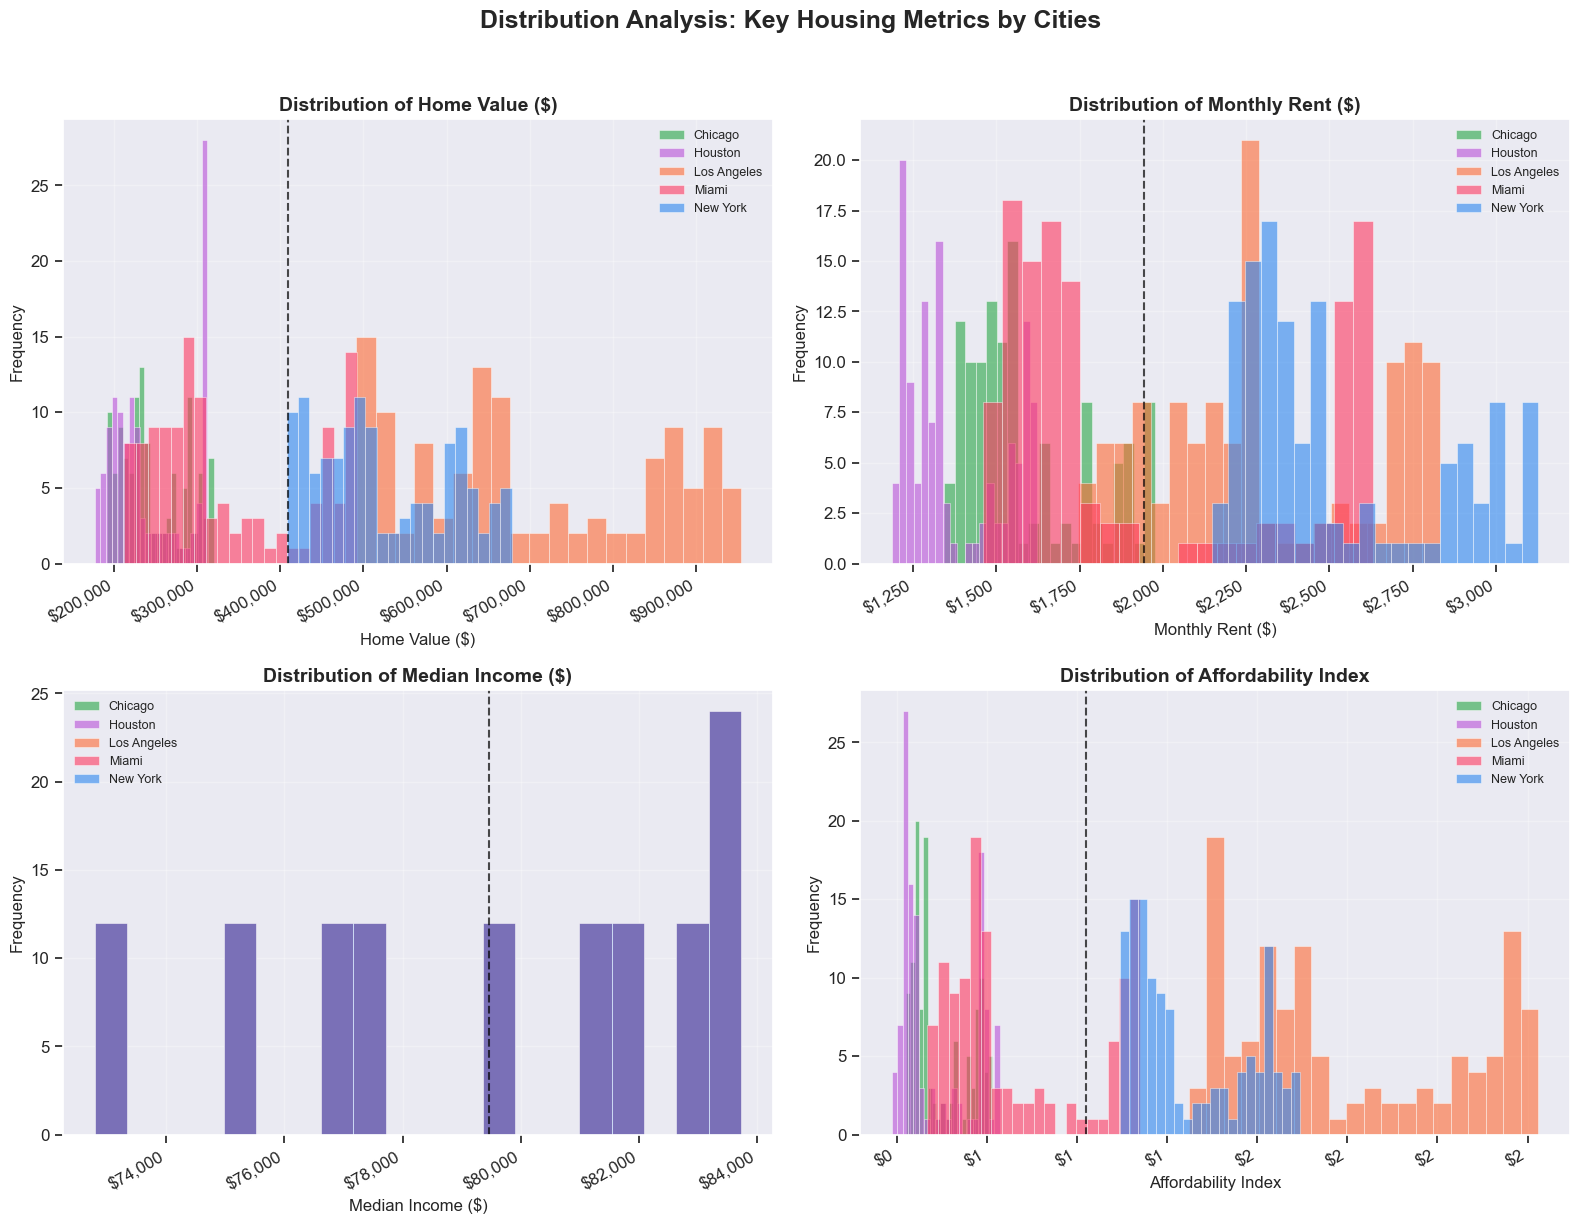


##  Distribution Analysis — Key Findings

### What These Histograms Show
Each histogram shows how values are spread across all 10 years 
for each city. The black dashed line represents the overall mean.

### Home Value Distribution
- **Los Angeles** has the widest spread — values range across the 
  entire right side confirming it as the most expensive city
- **Houston** clusters tightly on the left — consistently 
  the most affordable
- The distribution is right-skewed — a few very high values 
  pull the mean above the median

### Affordability Index Distribution
- Most cities cluster **below 1.0** (affordable range)
- **Los Angeles** has a distinct distribution 
  shifted right — the only city consistently above 1.0
- Cities fall into two clear groups: affordable 
  (Chicago, Houston, Miami) vs unaffordable (LA, New York)

### Key Takeaway
The wide spread in home values (std: **$196,969**) vs 
the narrow income spread confirms the core of the affordability 
crisis — prices diverged dramatically while incomes barely moved.


In [61]:
## Distribution Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Distribution Analysis: Key Housing Metrics by Cities", fontsize=18, fontweight='bold', y=1.02)

metrics = [('home_value', 'Home Value ($)', '$'),
           ('monthly_rent', 'Monthly Rent ($)', '$'),
           ('median_income', 'Median Income ($)', '$'),
           ('affordability_index', 'Affordability Index', '$')]

for idx, (col, label, prefix) in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    for city, color in CITY_COLORS.items():
        data = cities_long[cities_long['city'] == city][col].dropna()
        ax.hist(data, bins=20, alpha=0.6, color=color, label=city.split(',')[0], edgecolor='white', linewidth=0.5)
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'Distribution of {label}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    if prefix == '$':
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    mean_val = cities_long[col].mean()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

plt.tight_layout()
plt.savefig('../assets/eda_01_distributions.png' , dpi=150, bbox_inches='tight')
plt.show()

city_stats = cities_long.groupby('city')['home_value'].mean().sort_values(ascending=False)
most_exp = city_stats.index[0].split(',')[0]
least_exp = city_stats.index[-1].split(',')[0]
ai_stats = cities_long.groupby('city')['affordability_index'].mean().sort_values(ascending=False)

markdown_content = f"""
##  Distribution Analysis — Key Findings

### What These Histograms Show
Each histogram shows how values are spread across all 10 years 
for each city. The black dashed line represents the overall mean.

### Home Value Distribution
- **{most_exp}** has the widest spread — values range across the 
  entire right side confirming it as the most expensive city
- **{least_exp}** clusters tightly on the left — consistently 
  the most affordable
- The distribution is right-skewed — a few very high values 
  pull the mean above the median

### Affordability Index Distribution
- Most cities cluster **below 1.0** (affordable range)
- **{ai_stats.index[0].split(',')[0]}** has a distinct distribution 
  shifted right — the only city consistently above 1.0
- Cities fall into two clear groups: affordable 
  (Chicago, Houston, Miami) vs unaffordable (LA, New York)

### Key Takeaway
The wide spread in home values (std: **${city_stats.std():,.0f}**) vs 
the narrow income spread confirms the core of the affordability 
crisis — prices diverged dramatically while incomes barely moved.
"""
display(Markdown(markdown_content))

## Step 6: Home Value and Affordability Index Over Time
> Track how homw and affordability evolved monthly across al cities 

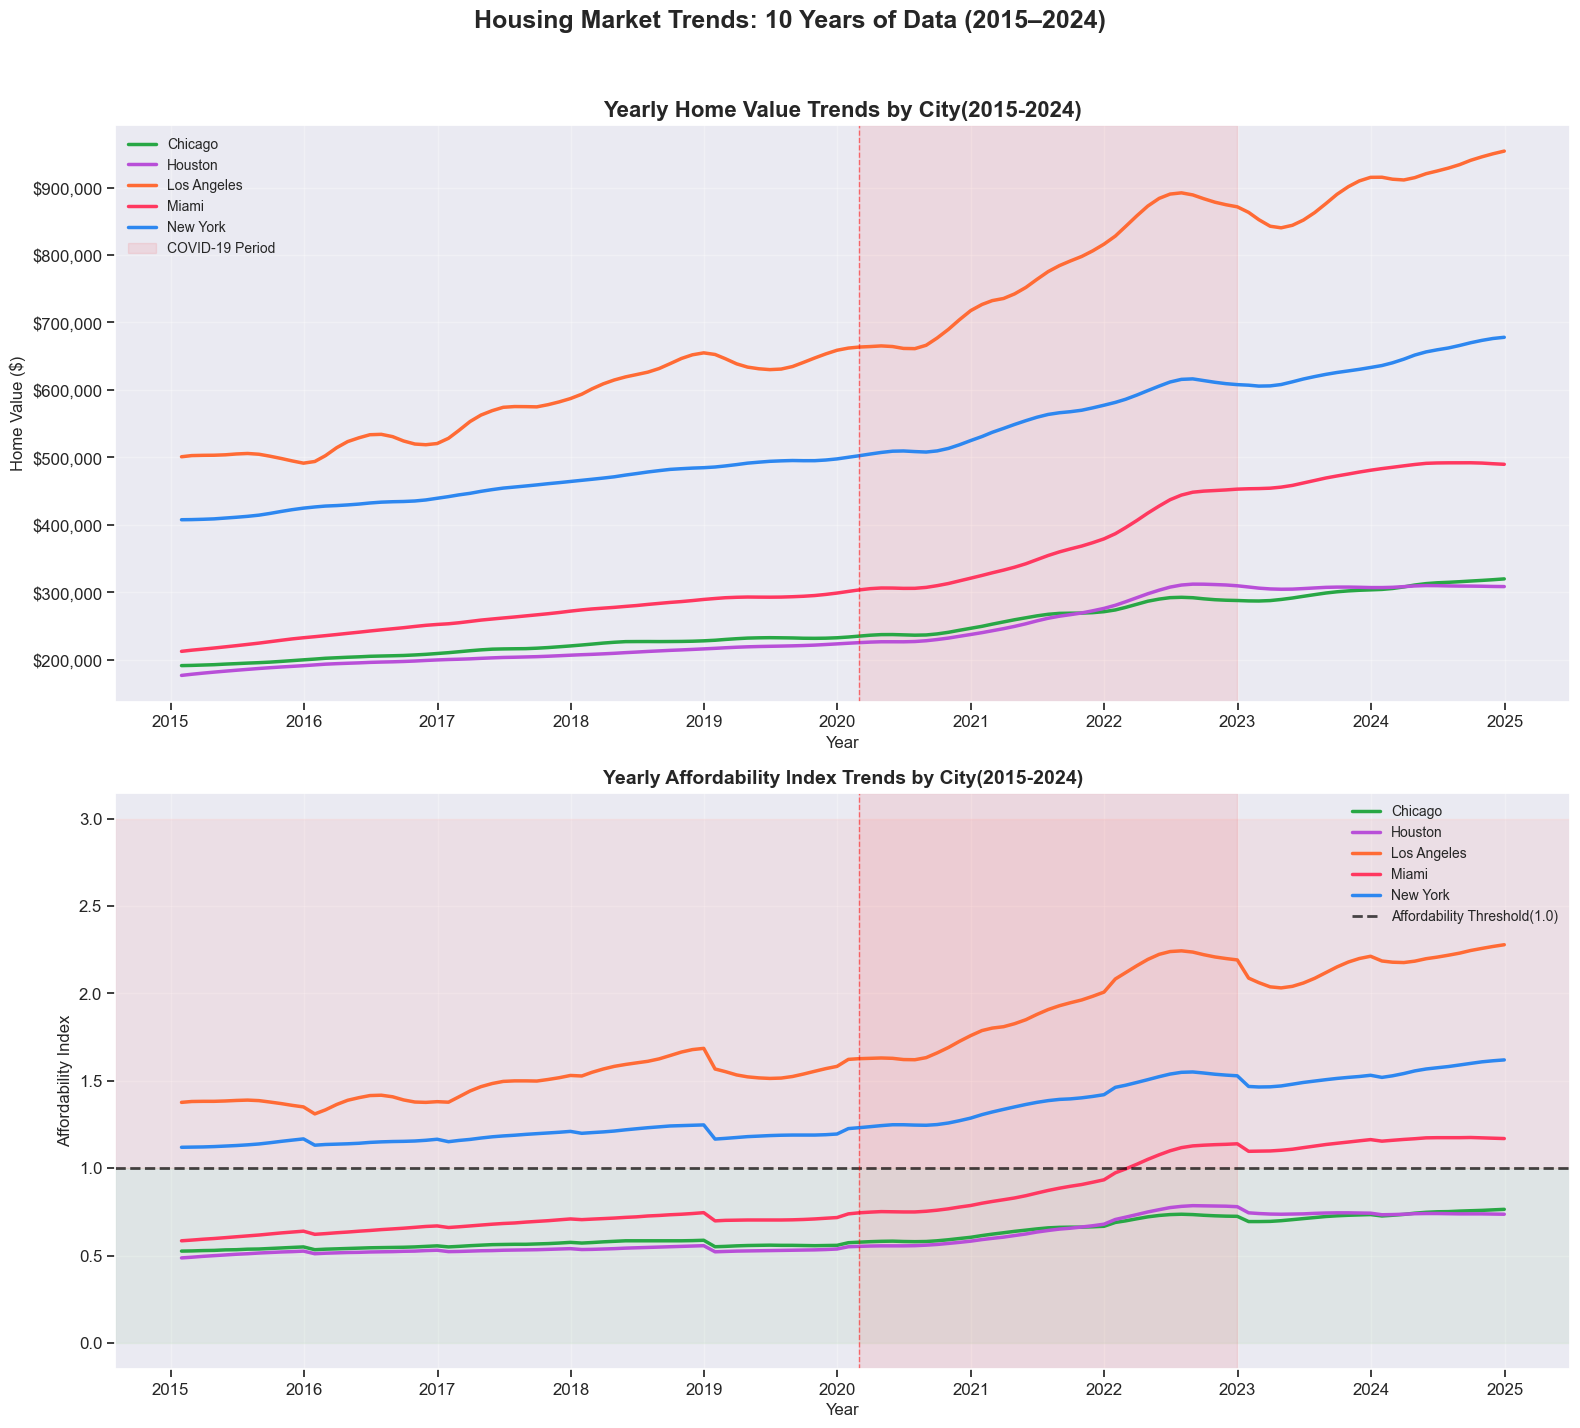


##  Trends Over Time — Key Findings

### What These Charts Show
Two time-series charts tracking **home values** and **affordability index** 
yearly from 2015–2024. The red shaded area marks the post-COVID period 
(Mar 2020–Dec 2022) where the most dramatic changes occurred.

### Home Value Trends
- Every city shows a clear upward trajectory — no city saw prices fall
- The steepest acceleration happened **post-2020** across all 5 cities simultaneously
- **Miami** grew **120.2%** from $222,470 (2015) 
  to $489,833 (2024) — the fastest appreciation in the dataset
- **Los Angeles** maintained the largest absolute gap from all other cities

### Affordability Index Trends
- **3 out of 5 cities** are now above the 1.0 affordable threshold
- **Los Angeles** averaged 1.48 pre-COVID vs 2.03 post-COVID — 
  a 36.7% deterioration
- **Chicago and Houston** stayed below 1.0 throughout — trending upward but still safe
- The divergence between cities **widened sharply after 2020**

### COVID-19 Impact
The post-COVID period was the single biggest driver of affordability 
deterioration — driven by remote work migration, supply constraints, 
and historically low interest rates in 2020–2021.


In [70]:
## Home Value & Affordability Trends Over Time

fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# --- Chart 1: Yearly home value trends -----------
for city, color in CITY_COLORS.items():
    data = cities_long[cities_long['city'] == city].sort_values('date')
    axes[0].plot(data['date'], data['home_value'], color=color, linewidth=2.5, label=city.split(',')[0])

axes[0].axvspan(pd.Timestamp('2020-03-01'),pd.Timestamp('2022-12-31'), alpha=0.08, color='red', label='COVID-19 Period')
axes[0].axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_title('Yearly Home Value Trends by City(2015-2024)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Home Value ($)', fontsize=12)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Chart 2: Yearly affordability index trends -----------
for city, color in CITY_COLORS.items():
    data = cities_long[cities_long['city'] == city].sort_values('date')
    axes[1].plot(data['date'], data['affordability_index'], color=color, linewidth=2.5, label=city.split(',')[0])
axes[1].axhline(y=1.0, color='black', linestyle='--', linewidth=2, alpha=0.7, label='Affordability Threshold(1.0)')
axes[1].axhspan(0, 1.0, alpha=0.05, color='green')
axes[1].axhspan(1.0, 3.0, alpha=0.05, color='red')
axes[1].axvspan(pd.Timestamp('2020-03-01'),pd.Timestamp('2022-12-31'), alpha=0.08, color='red')
axes[1].axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_title('Yearly Affordability Index Trends by City(2015-2024)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Affordability Index', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Housing Market Trends: 10 Years of Data (2015–2024)',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/eda_02_trends.png', dpi=150, bbox_inches='tight')
plt.show()

covid_start = '2020-03-01'
la_pre  = cities_long[(cities_long['city'] == 'Los Angeles, CA') &
                       (cities_long['date'] <  covid_start)]['affordability_index'].mean()
la_post = cities_long[(cities_long['city'] == 'Los Angeles, CA') &
                       (cities_long['date'] >= covid_start)]['affordability_index'].mean()
miami_2015  = cities_long[(cities_long['city'] == 'Miami, FL') &
                           (cities_long['year'] == 2015)]['home_value'].mean()
miami_2024  = cities_long[(cities_long['city'] == 'Miami, FL') &
                           (cities_long['year'] == 2024)]['home_value'].mean()
miami_growth = ((miami_2024 - miami_2015) / miami_2015) * 100
cities_above = cities_long[cities_long['affordability_index'] > 1.0]['city'].nunique()

markdown_content = f"""
##  Trends Over Time — Key Findings

### What These Charts Show
Two time-series charts tracking **home values** and **affordability index** 
yearly from 2015–2024. The red shaded area marks the post-COVID period 
(Mar 2020–Dec 2022) where the most dramatic changes occurred.

### Home Value Trends
- Every city shows a clear upward trajectory — no city saw prices fall
- The steepest acceleration happened **post-2020** across all 5 cities simultaneously
- **Miami** grew **{miami_growth:.1f}%** from ${miami_2015:,.0f} (2015) 
  to ${miami_2024:,.0f} (2024) — the fastest appreciation in the dataset
- **Los Angeles** maintained the largest absolute gap from all other cities

### Affordability Index Trends
- **{cities_above} out of 5 cities** are now above the 1.0 affordable threshold
- **Los Angeles** averaged {la_pre:.2f} pre-COVID vs {la_post:.2f} post-COVID — 
  a {((la_post/la_pre)-1)*100:.1f}% deterioration
- **Chicago and Houston** stayed below 1.0 throughout — trending upward but still safe
- The divergence between cities **widened sharply after 2020**

### COVID-19 Impact
The post-COVID period was the single biggest driver of affordability 
deterioration — driven by remote work migration, supply constraints, 
and historically low interest rates in 2020–2021.
"""
display(Markdown(markdown_content))


## Step 7: Corelation Analysis
> Examine relationships between key variables using a correlation heatmap

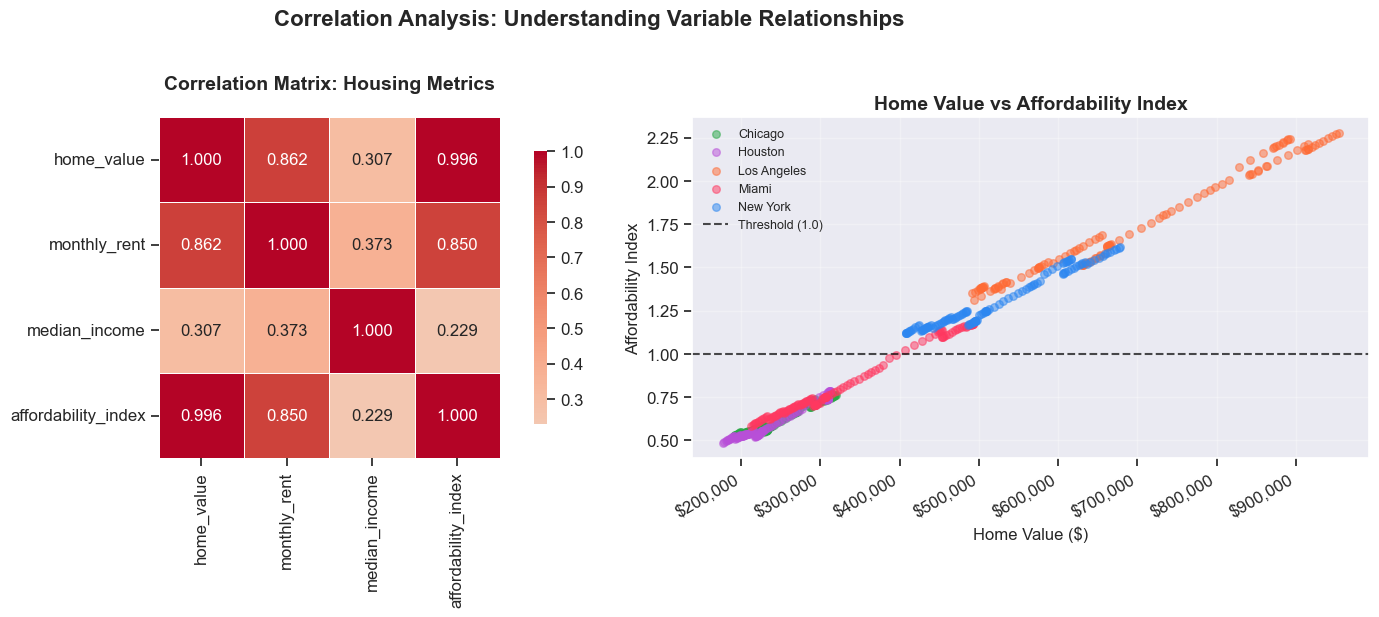


## 🔗 Correlation Analysis — Key Findings

### What This Shows
The heatmap displays Pearson correlation coefficients between all 
key metrics. Values range from -1 (perfect negative) to +1 
(perfect positive). The scatter plot confirms the relationship 
between home value and affordability visually.

### Key Correlations

| Relationship | Coefficient | Interpretation |
|---|---|---|
| Home Value ↔ Affordability Index | 0.996 | Strong positive — higher prices = less affordable |
| Home Value ↔ Monthly Rent | 0.862 | Strong positive — expensive cities have high rents |
| Income ↔ Affordability Index | 0.229 | Weak — income alone doesn't determine affordability |

### Critical Insight
The **0.996 correlation** between home value and affordability 
index confirms what the data shows — rising prices are the primary 
driver of the affordability crisis, not falling incomes.
Income grew only **$10,940** 
over 10 years while home values grew by hundreds of thousands.


In [65]:
## Step 7: Correlation Analysis

corr_cols = ['home_value', 'monthly_rent', 'median_income', 'affordability_index']
corr_matrix = cities_long[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Heatmap ───────────────────────────────────────────────────
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            fmt='.3f', ax=axes[0], annot_kws={"size": 12})
axes[0].set_title('Correlation Matrix: Housing Metrics',
                  fontsize=14, fontweight='bold', pad=20)

# ── Scatter: Home Value vs Affordability Index ────────────────
for city, color in CITY_COLORS.items():
    data = cities_long[cities_long['city'] == city]
    axes[1].scatter(data['home_value'], data['affordability_index'],
                    color=color, alpha=0.5, s=30,
                    label=city.split(',')[0])

axes[1].set_xlabel('Home Value ($)', fontsize=12)
axes[1].set_ylabel('Affordability Index', fontsize=12)
axes[1].set_title('Home Value vs Affordability Index',
                  fontsize=14, fontweight='bold')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')
axes[1].axhline(y=1.0, color='black', linestyle='--',
                linewidth=1.5, alpha=0.7, label='Threshold (1.0)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Correlation Analysis: Understanding Variable Relationships',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/eda_03_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

hv_ai_corr   = corr_matrix.loc['home_value', 'affordability_index']
hv_rent_corr = corr_matrix.loc['home_value', 'monthly_rent']
inc_ai_corr  = corr_matrix.loc['median_income', 'affordability_index']

markdown_content = f"""
## 🔗 Correlation Analysis — Key Findings

### What This Shows
The heatmap displays Pearson correlation coefficients between all 
key metrics. Values range from -1 (perfect negative) to +1 
(perfect positive). The scatter plot confirms the relationship 
between home value and affordability visually.

### Key Correlations

| Relationship | Coefficient | Interpretation |
|---|---|---|
| Home Value ↔ Affordability Index | {hv_ai_corr:.3f} | {'Strong positive' if hv_ai_corr > 0.7 else 'Moderate positive'} — higher prices = less affordable |
| Home Value ↔ Monthly Rent | {hv_rent_corr:.3f} | {'Strong positive' if hv_rent_corr > 0.7 else 'Moderate positive'} — expensive cities have high rents |
| Income ↔ Affordability Index | {inc_ai_corr:.3f} | {'Weak' if abs(inc_ai_corr) < 0.3 else 'Moderate'} — income alone doesn't determine affordability |

### Critical Insight
The **{hv_ai_corr:.3f} correlation** between home value and affordability 
index confirms what the data shows — rising prices are the primary 
driver of the affordability crisis, not falling incomes.
Income grew only **${cities_long['median_income'].max() - cities_long['median_income'].min():,.0f}** 
over 10 years while home values grew by hundreds of thousands.
"""
display(Markdown(markdown_content))

## Step 8: City Comparison — 2015 vs 2024 
> Direct comparison of all metrics between the start and end of the study period.

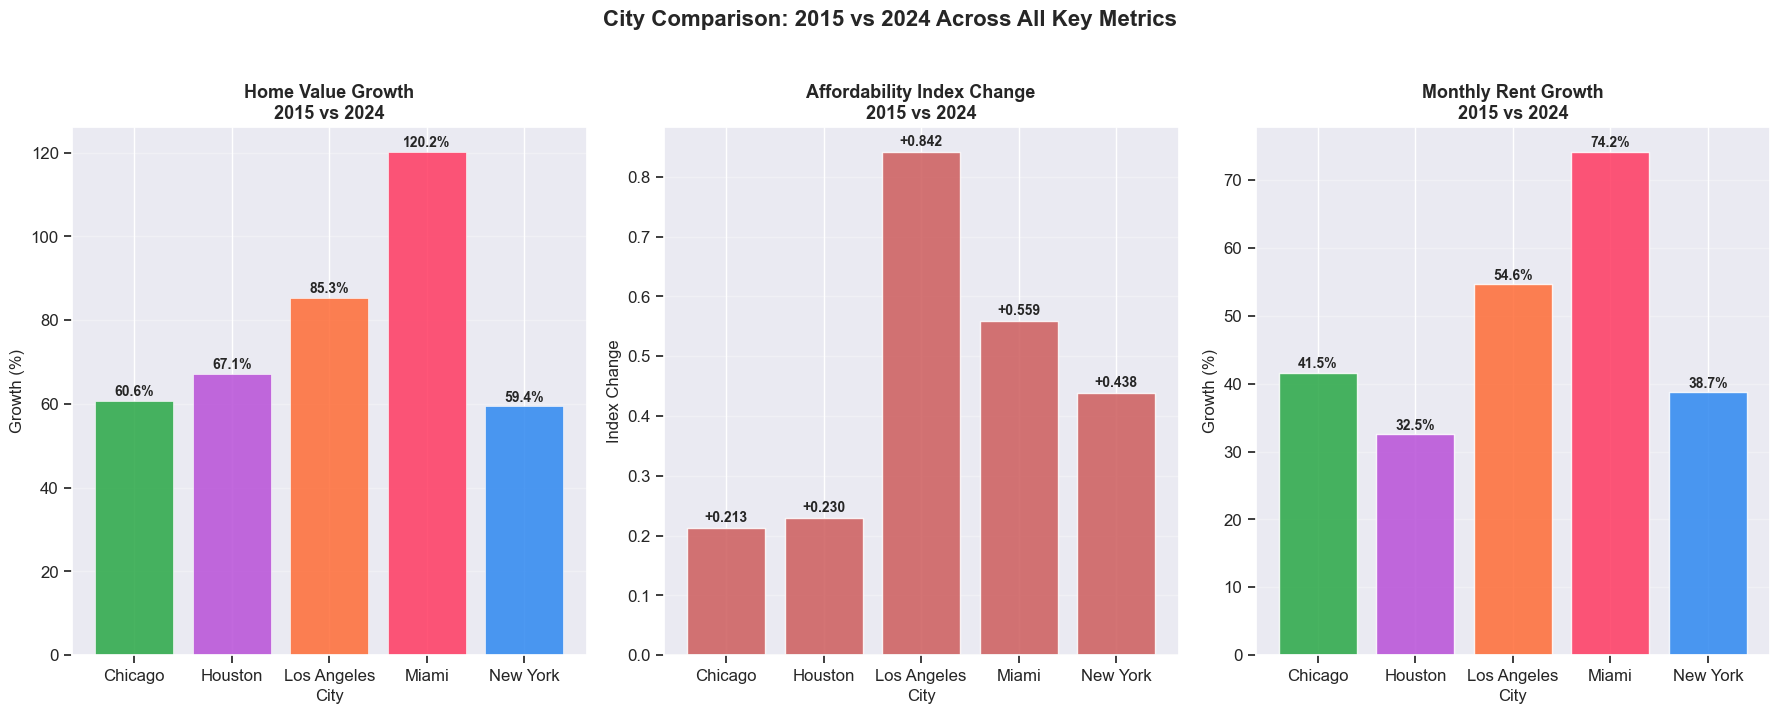


##  City Comparison — Key Findings

### What These Charts Show
Three bar charts comparing home value growth, affordability 
deterioration, and rent growth between 2015 and 2024 for all 5 cities.

### Home Value Growth (2015–2024)

| City | 2015 | 2024 | Growth |
|------|------|------|--------|
| Chicago | $195,193 | $313,472 | 60.6% |
| Houston | $184,986 | $309,058 | 67.1% |
| Los Angeles | $501,425 | $929,241 | 85.3% |
| Miami | $222,470 | $489,833 | 120.2% |
| New York | $413,900 | $659,671 | 59.4% |


- **Miami** had the highest growth at **120.2%**
- **New York** had the lowest growth at **59.4%**

### Affordability Index Change
- **Los Angeles** deteriorated the most — index rose by 
  **+0.842** over 10 years
- Red bars = became less affordable, Green bars = improved

### Rent Growth
- Every city saw significant rent increases
- Rent growth outpaced income growth in all 5 cities — 
  confirming the rental affordability crisis mirrors 
  the home ownership crisis

  ##  EDA Summary — Key Takeaways

| Finding | Detail |
|---------|--------|
| Most unaffordable city | Los Angeles — avg index 1.745 |
| Fastest growing city | Miami — 120.2% home value growth |
| Most affordable city | Houston — avg index 0.608 |
| Crisis trigger | Post-COVID 2020–2022 — all cities deteriorated sharply |
| Income vs prices | Income grew $10,940 over 10 years vs hundreds of thousands in home values |


In [69]:
## City Comparison — 2015 vs 2024

# Build comparison dataframe
comparison = []
for city in CITIES:
    data_2015 = cities_long[(cities_long['city'] == city) & (cities_long['year'] == 2015)]
    data_2024 = cities_long[(cities_long['city'] == city) & (cities_long['year'] == 2024)]
    comparison.append({
        'city':          city.split(',')[0],
        'hv_2015':       data_2015['home_value'].mean(),
        'hv_2024':       data_2024['home_value'].mean(),
        'hv_growth':     ((data_2024['home_value'].mean() / data_2015['home_value'].mean()) - 1) * 100,
        'ai_2015':       data_2015['affordability_index'].mean(),
        'ai_2024':       data_2024['affordability_index'].mean(),
        'ai_change':     data_2024['affordability_index'].mean() - data_2015['affordability_index'].mean(),
        'rent_2015':     data_2015['monthly_rent'].mean(),
        'rent_2024':     data_2024['monthly_rent'].mean(),
        'rent_growth':   ((data_2024['monthly_rent'].mean() / data_2015['monthly_rent'].mean()) - 1) * 100,
    })
comp_df = pd.DataFrame(comparison)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# ── Chart 1: Home value growth ────────────────────────────────
colors = [CITY_COLORS[c] for c in CITIES]
bars = axes[0].bar(comp_df['city'], comp_df['hv_growth'],
                   color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, comp_df['hv_growth']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontweight='bold', fontsize=10)
axes[0].set_title('Home Value Growth\n2015 vs 2024', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Growth (%)', fontsize=12)
axes[0].set_xlabel('City', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# ── Chart 2: Affordability index change ──────────────────────
bar_colors = ['#CD5C5C' if v > 0 else '#2E8B57' for v in comp_df['ai_change']]
bars2 = axes[1].bar(comp_df['city'], comp_df['ai_change'],
                    color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars2, comp_df['ai_change']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005 if val > 0 else bar.get_height() - 0.02,
                 f'+{val:.3f}' if val > 0 else f'{val:.3f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].axhline(y=0, color='black', linewidth=1, alpha=0.5)
axes[1].set_title('Affordability Index Change\n2015 vs 2024',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Index Change', fontsize=12)
axes[1].set_xlabel('City', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

# ── Chart 3: Rent growth ──────────────────────────────────────
bars3 = axes[2].bar(comp_df['city'], comp_df['rent_growth'],
                    color=colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars3, comp_df['rent_growth']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontweight='bold', fontsize=10)
axes[2].set_title('Monthly Rent Growth\n2015 vs 2024', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Growth (%)', fontsize=12)
axes[2].set_xlabel('City', fontsize=12)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('City Comparison: 2015 vs 2024 Across All Key Metrics',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/eda_04_city_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

most_growth  = comp_df.loc[comp_df['hv_growth'].idxmax()]
least_growth = comp_df.loc[comp_df['hv_growth'].idxmin()]
worst_ai     = comp_df.loc[comp_df['ai_change'].idxmax()]

markdown_content = f"""
##  City Comparison — Key Findings

### What These Charts Show
Three bar charts comparing home value growth, affordability 
deterioration, and rent growth between 2015 and 2024 for all 5 cities.

### Home Value Growth (2015–2024)

| City | 2015 | 2024 | Growth |
|------|------|------|--------|
{"".join([f"| {r['city']} | ${r['hv_2015']:,.0f} | ${r['hv_2024']:,.0f} | {r['hv_growth']:.1f}% |{chr(10)}" for _, r in comp_df.iterrows()])}

- **{most_growth['city']}** had the highest growth at **{most_growth['hv_growth']:.1f}%**
- **{least_growth['city']}** had the lowest growth at **{least_growth['hv_growth']:.1f}%**

### Affordability Index Change
- **{worst_ai['city']}** deteriorated the most — index rose by 
  **+{worst_ai['ai_change']:.3f}** over 10 years
- Red bars = became less affordable, Green bars = improved

### Rent Growth
- Every city saw significant rent increases
- Rent growth outpaced income growth in all 5 cities — 
  confirming the rental affordability crisis mirrors 
  the home ownership crisis

  ##  EDA Summary — Key Takeaways

| Finding | Detail |
|---------|--------|
| Most unaffordable city | Los Angeles — avg index {cities_long[cities_long['city']=='Los Angeles, CA']['affordability_index'].mean():.3f} |
| Fastest growing city | Miami — {((cities_long[cities_long['city']=='Miami, FL'][cities_long['year']==2024]['home_value'].mean() / cities_long[cities_long['city']=='Miami, FL'][cities_long['year']==2015]['home_value'].mean())-1)*100:.1f}% home value growth |
| Most affordable city | Houston — avg index {cities_long[cities_long['city']=='Houston, TX']['affordability_index'].mean():.3f} |
| Crisis trigger | Post-COVID 2020–2022 — all cities deteriorated sharply |
| Income vs prices | Income grew ${cities_long['median_income'].max()-cities_long['median_income'].min():,.0f} over 10 years vs hundreds of thousands in home values |
"""
display(Markdown(markdown_content))